In [1]:
import numpy as np
from matplotlib import pyplot as plt
import ANNarchy as ann
from tvb_multiscale.tvb_annarchy.annarchy.models import Izhikevich_Hamker, Izhikevich_Hamker_Proxy

TEST = "CURRENT" # "CURRENT" # "RATE"

ANNarchy 4.8 (4.8.0) on linux (posix).


In [2]:
DT = 0.005
ann.setup(dt=DT)

In [3]:
if TEST == "CURRENT":
    geometry = 600
    
    inp = ann.TimedArray(geometry=geometry)
    proxy = ann.Population(geometry, neuron=Izhikevich_Hamker_Proxy)
    neuron = ann.Population(geometry, neuron=Izhikevich_Hamker)
    
    inp_to_proxy = ann.CurrentInjection(inp, proxy, "ampa")
    inp_to_proxy.connect_current()
    
    proxy_to_neuron = ann.Projection(proxy, neuron, "ampa")
    proxy_to_neuron.connect_fixed_probability(probability=0.1, weights=0.025)
    
    mP = ann.Monitor(proxy, ['g_ampa', 'spike'], period=1.0)
    mI = ann.Monitor(inp, 'r', period=1.0)
else:
    geometry = 100
    
    inp = ann.TimedPoissonPopulation(geometry, np.zeros((geometry, 1)), np.zeros((geometry,)))
    neuron = ann.Population(geometry, neuron=Izhikevich_Hamker)
    
    inp_to_neuron = ann.Projection(inp, neuron, "ampa")
    inp_to_neuron.connect_fixed_probability(probability=0.1, weights=0.25)
    
    mI = ann.Monitor(inp, ['r', 'spike'])

mN = ann.Monitor(neuron, ['g_ampa', 'spike'], period=1.0)

In [4]:
ann.compile()

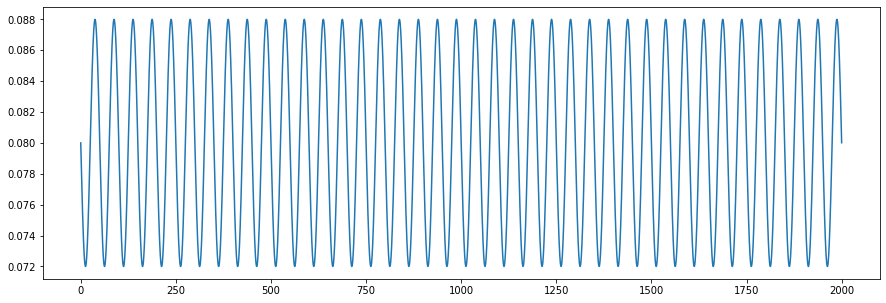

In [5]:
DT_RATIO = 2
TVB_DT = DT_RATIO*DT
T = 2 * 1000.0 # ms
f = 20.0 / 1000  
omega = 2 *np.pi * f
time = np.arange(0.0, T, TVB_DT)
if TEST == "CURRENT":
    r0 = 0.08
    amplratio = 0.1
else:
    r0 = 12.0
    amplratio = 1.0
rates = r0 * (1 - amplratio*np.sin(time*omega))
plt.figure(figsize=(15, 5))
plt.plot(time, rates)
rates = rates[:, np.newaxis] * np.ones((1, geometry))
schedule = time


In [6]:
Tsync = 1.16
Nsync = int(Tsync/TVB_DT)
print("Tsync = %g ms" % Tsync)
print("Nsync = %d TVB time steps" % Nsync)
t = 0.0
while t <= T-Tsync:
    it = int(t/TVB_DT)
    if TEST == "CURRENT":
        inp.update(rates[it:it+Nsync], schedule[it:it+Nsync])
    else:
        inp.schedule = schedule[it:it+Nsync]
        inp.rates = rates[it:it+Nsync]
    ann.simulate(Tsync)
    # t += Tsync
    t = ann.get_time()
    
# inp.update(rates, schedule)
# ann.simulate(T)

Tsync = 1.16 ms
Nsync = 115 TVB time steps


In [7]:
def get_plot_spikes(m, smooth=100.0):
    spikes = m.get('spike')
    spike_times, ranks = m.raster_plot(spikes)
    fig, axes = plt.subplots(2, 1, figsize=(15, 6))
    axes[0].plot(spike_times, ranks, '.')
    axes[0].set_title("spikes")
    axes[0].set_ylabel("neuron")
    rates = m.population_rate(spikes, smooth=smooth)
    time = np.linspace(0, ann.get_time(), len(rates))
    axes[1].plot(time, rates)
    axes[1].set_title("r (smooth=%g ms)" % smooth)
    axes[1].set_xlabel("time")
    return spike_times, ranks, spikes, m, fig, axes


def get_plot_vars(m, vrs=["r", "g_ampa"]):
    times = m.times()
    outputs = {}
    ts = {}
    fig, axes = plt.subplots(len(vrs), 1, figsize=(15, 6))
    if len(vrs) == 1:
        axes = [axes]
    for iV, var in enumerate(vrs):
        outputs[var] = m.get(var)
        ts[var] = np.linspace(times[var]["start"][0], ann.get_time(), len(outputs[var]))
        axes[iV].plot(ts[var], outputs[var])
        axes[iV].set_title(var)
    axes[-1].set_xlabel("time")
    fig.show()
    return outputs, ts, m, fig, axes




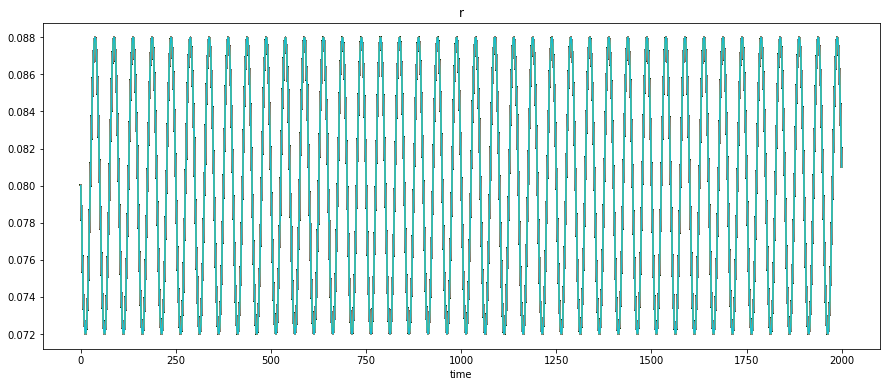

In [8]:
outputsI, tsI, mi, figI, axesI = get_plot_vars(mI, vrs=["r"])

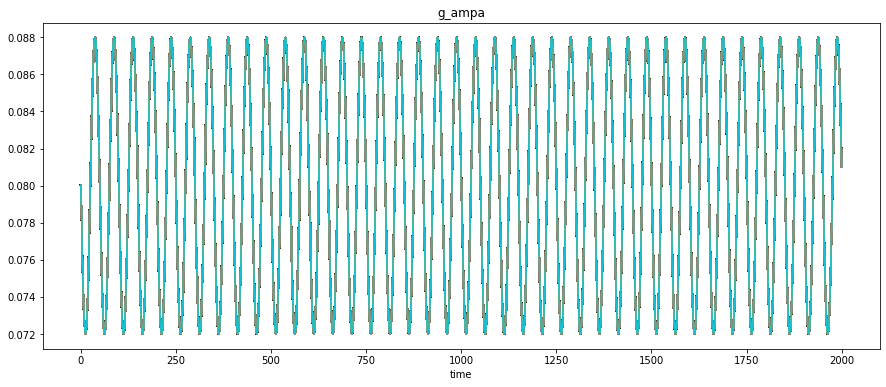

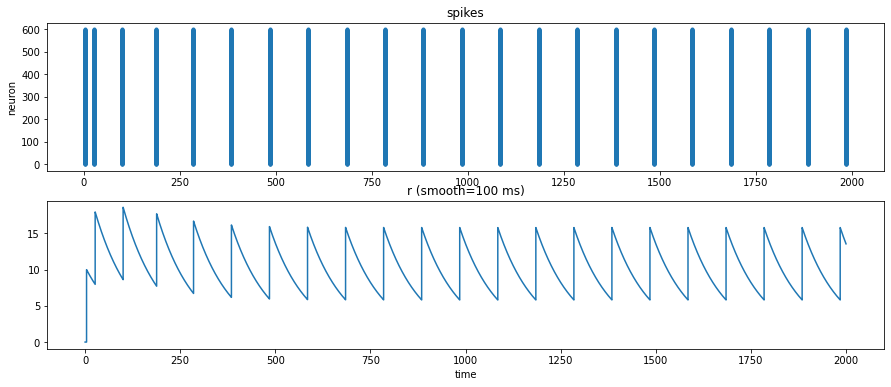

In [9]:
if TEST == "CURRENT":
    outputsP, tsP, mP, figP, axesP  = get_plot_vars(mP, vrs=["g_ampa"])
    spike_timesP, ranksP, spikesP, mP, figPsp, axesPsp = get_plot_spikes(mP)
else:
    spike_timesI, ranksI, spikesI, mI, figIsp, axesIsp = get_plot_spikes(mI)

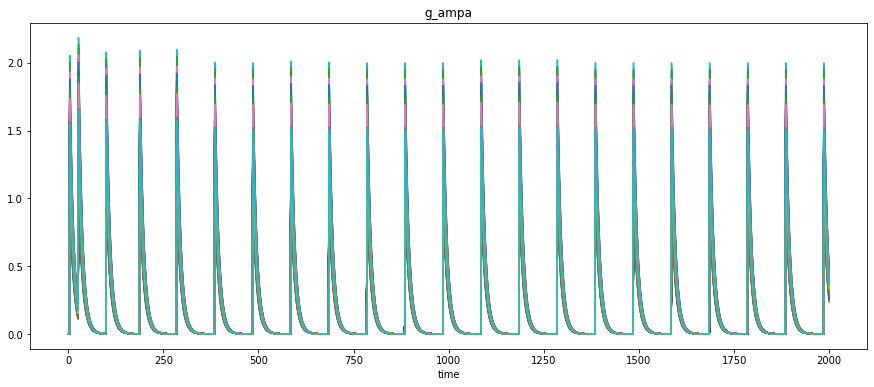

In [10]:
outputsN, tsN, mN, figN, axesN  = get_plot_vars(mN, vrs=["g_ampa"])

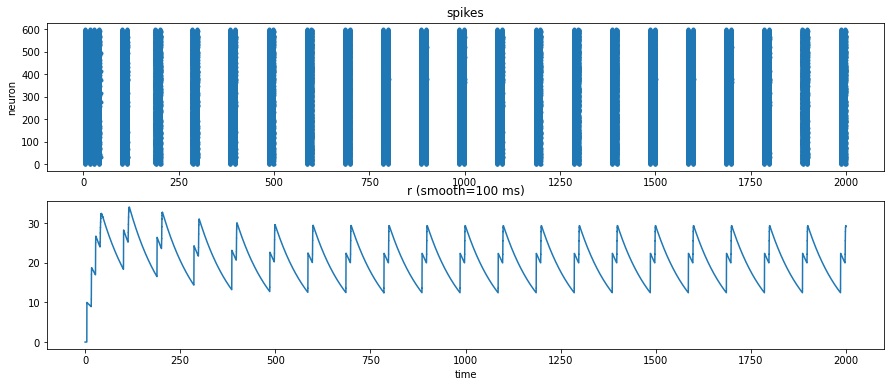

In [11]:
spike_timesN, ranksN, spikesN, mN, figNsp, axesNsp = get_plot_spikes(mN)